In [8]:
pip install ucimlrepo

Dataset shape: (581012, 54)
Target shape: (581012,)
Number of classes: 7

Class Distribution:
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64


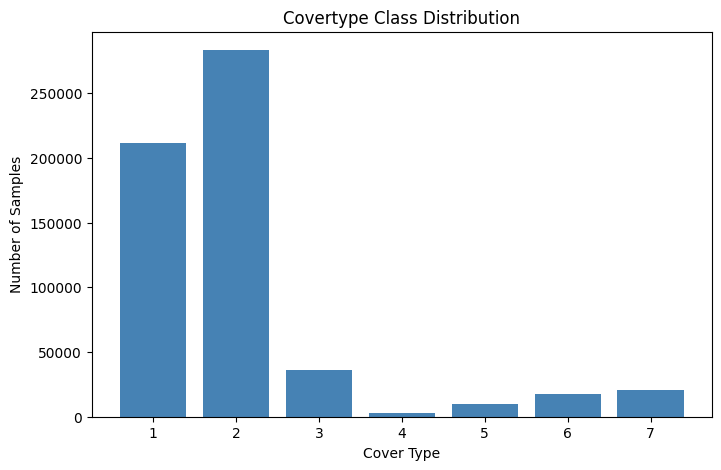

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
covertype = fetch_ucirepo(id=31)

X = covertype.data.features.to_numpy(dtype=np.float32)
y = covertype.data.targets.to_numpy().ravel().astype(int)

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)
print("Number of classes:", len(np.unique(y)))
class_counts = pd.Series(y).value_counts().sort_index()

print("\nClass Distribution:")
print(class_counts)

plt.figure(figsize=(8, 5))
plt.bar(
    class_counts.index,
    class_counts.values,
    color="steelblue"
)

plt.xlabel("Cover Type")
plt.ylabel("Number of Samples")
plt.title("Covertype Class Distribution")
plt.xticks(range(1, 8))
plt.show()

In [14]:
most_frequent = class_counts.max()
least_frequent = class_counts.min()

imbalance_ratio = most_frequent / least_frequent

print("Most frequent class:", class_counts.idxmax())
print("Least frequent class:", class_counts.idxmin())
print("Imbalance ratio:",
      round(imbalance_ratio, 2))


Most frequent class: 2
Least frequent class: 4
Imbalance ratio: 103.13


In [15]:
print("\nNumber of features:", X.shape[1])
print("Number of classes:", len(np.unique(y)))

# Convert classes 1-7 to 0-6
y = y - 1

print("Classes after conversion:", np.unique(y))



Number of features: 54
Number of classes: 7
Classes after conversion: [0 1 2 3 4 5 6]


In [16]:
K = 7

Y = np.eye(K)[y].astype(np.float32)

print("One-hot target shape:", Y.shape)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("\nTraining:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)


One-hot target shape: (581012, 7)

Training: (464809, 54)
Validation: (58101, 54)
Testing: (58102, 54)


In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

print("\nTraining mean:",
      np.mean(X_train, axis=0)[:5])

print("Training standard deviation:",
      np.std(X_train, axis=0)[:5])


Training mean: [-1.8026466e-08 -2.5448384e-07 -5.5451764e-08 -2.6393087e-07
 -2.0168498e-08]
Training standard deviation: [0.99988407 0.99983937 1.0005753  0.999666   0.99981916]


In [18]:
N = len(y_train)

class_counts_train = np.bincount(
    y_train,
    minlength=K
)

class_weights = N / (
    K * class_counts_train
)

print("\nClass weights:")

for c in range(K):
    print(
        f"Class {c}: "
        f"{class_weights[c]:.4f}"
    )



Class weights:
Class 0: 0.3918
Class 1: 0.2930
Class 2: 2.3215
Class 3: 30.2099
Class 4: 8.7439
Class 5: 4.7791
Class 6: 4.0469


In [19]:
layers = [54, 64, 32, 16, 7]

rng = np.random.default_rng(42)

W = []
b = []

# He initialization
for i in range(4):

    W.append(
        (
            rng.standard_normal(
                (layers[i], layers[i + 1])
            )
            * np.sqrt(2 / layers[i])
        ).astype(np.float32)
    )

    b.append(
        np.zeros(
            (1, layers[i + 1]),
            dtype=np.float32
        )
    )

print("\nNetwork architecture:", layers)



Network architecture: [54, 64, 32, 16, 7]


In [21]:
def relu(x):
    return np.maximum(0, x)


def softmax(x):
    x = x - np.max(
        x,
        axis=1,
        keepdims=True
    )

    exp_x = np.exp(x)

    return exp_x / np.sum(
        exp_x,
        axis=1,
        keepdims=True
    )


def forward(X):

    Z1 = X @ W[0] + b[0]
    A1 = relu(Z1)

    Z2 = A1 @ W[1] + b[1]
    A2 = relu(Z2)

    Z3 = A2 @ W[2] + b[2]
    A3 = relu(Z3)

    Z4 = A3 @ W[3] + b[3]

    # Softmax output
    A4 = softmax(Z4)

    return A4, (X, Z1, A1, Z2, A2, Z3, A3)


In [22]:
def loss(Y, P):

    sample_weights = np.sum(
        Y * class_weights,
        axis=1
    )

    return -np.mean(
        sample_weights *
        np.sum(
            Y * np.log(P + 1e-12),
            axis=1
        )
    )

In [23]:
learning_rate = 0.01
batch_size = 128
epochs = 100
patience = 15

Y_train = np.eye(K)[y_train].astype(np.float32)
Y_val = np.eye(K)[y_val].astype(np.float32)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}

best_loss = np.inf
best_W = [w.copy() for w in W]
best_b = [x.copy() for x in b]

wait = 0

for epoch in range(epochs):


    indices = rng.permutation(len(X_train))

    X_train = X_train[indices]
    y_train = y_train[indices]
    Y_train = Y_train[indices]

    for start in range(
        0,
        len(X_train),
        batch_size
    ):

        Xb = X_train[
            start:start + batch_size
        ]

        Yb = Y_train[
            start:start + batch_size
        ]


        P, cache = forward(Xb)

        X0, Z1, A1, Z2, A2, Z3, A3 = cache

        sample_weights = np.sum(
            Yb * class_weights,
            axis=1,
            keepdims=True
        )

        dZ4 = (
            (P - Yb)
            * sample_weights
            / len(Xb)
        )


        dW4 = A3.T @ dZ4
        db4 = np.sum(
            dZ4,
            axis=0,
            keepdims=True
        )


        dA3 = dZ4 @ W[3].T
        dZ3 = dA3 * (Z3 > 0)

        dW3 = A2.T @ dZ3
        db3 = np.sum(
            dZ3,
            axis=0,
            keepdims=True
        )


        dA2 = dZ3 @ W[2].T
        dZ2 = dA2 * (Z2 > 0)

        dW2 = A1.T @ dZ2
        db2 = np.sum(
            dZ2,
            axis=0,
            keepdims=True
        )


        dA1 = dZ2 @ W[1].T
        dZ1 = dA1 * (Z1 > 0)

        dW1 = X0.T @ dZ1
        db1 = np.sum(
            dZ1,
            axis=0,
            keepdims=True
        )


        W[0] -= learning_rate * dW1
        b[0] -= learning_rate * db1

        W[1] -= learning_rate * dW2
        b[1] -= learning_rate * db2

        W[2] -= learning_rate * dW3
        b[2] -= learning_rate * db3

        W[3] -= learning_rate * dW4
        b[3] -= learning_rate * db4



    train_P, _ = forward(X_train)
    val_P, _ = forward(X_val)

    train_loss = loss(
        Y_train,
        train_P
    )

    val_loss = loss(
        Y_val,
        val_P
    )

    train_pred = np.argmax(
        train_P,
        axis=1
    )

    val_pred = np.argmax(
        val_P,
        axis=1
    )

    train_accuracy = np.mean(
        train_pred == y_train
    )

    val_accuracy = np.mean(
        val_pred == y_val
    )

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_accuracy"].append(
        val_accuracy
    )

    print(
        f"Epoch {epoch + 1:3d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

    if val_loss < best_loss:

        best_loss = val_loss

        best_W = [
            w.copy()
            for w in W
        ]

        best_b = [
            x.copy()
            for x in b
        ]

        wait = 0

    else:

        wait += 1

        if wait >= patience:

            print("Early stopping.")
            break

W = best_W
b = best_b

Epoch   1 | Train Loss: 0.6831 | Val Loss: 0.6939 | Train Acc: 0.6013 | Val Acc: 0.6018
Epoch   2 | Train Loss: 0.6095 | Val Loss: 0.6212 | Train Acc: 0.6325 | Val Acc: 0.6326
Epoch   3 | Train Loss: 0.5715 | Val Loss: 0.5793 | Train Acc: 0.6566 | Val Acc: 0.6587
Epoch   4 | Train Loss: 0.5333 | Val Loss: 0.5420 | Train Acc: 0.6666 | Val Acc: 0.6681
Epoch   5 | Train Loss: 0.5255 | Val Loss: 0.5302 | Train Acc: 0.6617 | Val Acc: 0.6618
Epoch   6 | Train Loss: 0.5018 | Val Loss: 0.5085 | Train Acc: 0.6966 | Val Acc: 0.6982
Epoch   7 | Train Loss: 0.5049 | Val Loss: 0.5098 | Train Acc: 0.6673 | Val Acc: 0.6697
Epoch   8 | Train Loss: 0.4913 | Val Loss: 0.5007 | Train Acc: 0.7047 | Val Acc: 0.7064
Epoch   9 | Train Loss: 0.4968 | Val Loss: 0.4992 | Train Acc: 0.6775 | Val Acc: 0.6782
Epoch  10 | Train Loss: 0.4601 | Val Loss: 0.4679 | Train Acc: 0.7267 | Val Acc: 0.7263
Epoch  11 | Train Loss: 0.4560 | Val Loss: 0.4645 | Train Acc: 0.7221 | Val Acc: 0.7219
Epoch  12 | Train Loss: 0.4437 |

In [24]:
test_probabilities, _ = forward(X_test)

y_pred = np.argmax(
    test_probabilities,
    axis=1
)


In [25]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test, y_pred,
    average=None,
    zero_division=0
)

recall = recall_score(
    y_test, y_pred,
    average=None,
    zero_division=0
)

f1 = f1_score(
    y_test, y_pred,
    average=None,
    zero_division=0
)

macro_precision = precision_score(
    y_test, y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_test, y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_test, y_pred,
    average="macro",
    zero_division=0
)

print("\nAccuracy:", round(accuracy, 4))
print("Macro Precision:", round(macro_precision, 4))
print("Macro Recall:", round(macro_recall, 4))
print("Macro F1:", round(macro_f1, 4))

metrics = pd.DataFrame({
    "Class": range(1, 8),
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
})

print("\nPer-Class Metrics:")
print(metrics.round(4))


Accuracy: 0.8051
Macro Precision: 0.686
Macro Recall: 0.8845
Macro F1: 0.7549

Per-Class Metrics:
   Class  Precision  Recall  F1-Score
0      1     0.8084  0.8132    0.8108
1      2     0.8724  0.7713    0.8187
2      3     0.8332  0.8412    0.8372
3      4     0.5902  0.9672    0.7331
4      5     0.3887  0.9399    0.5499
5      6     0.5779  0.8803    0.6977
6      7     0.7311  0.9785    0.8369


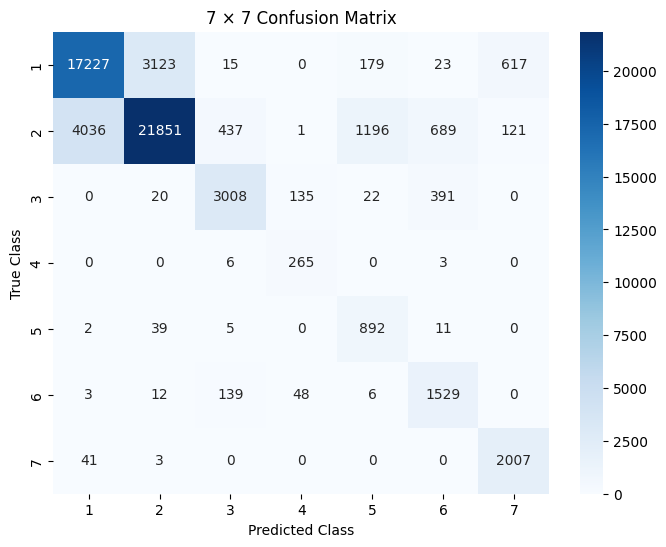

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(1, 8),
    yticklabels=range(1, 8)
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("7 × 7 Confusion Matrix")
plt.show()

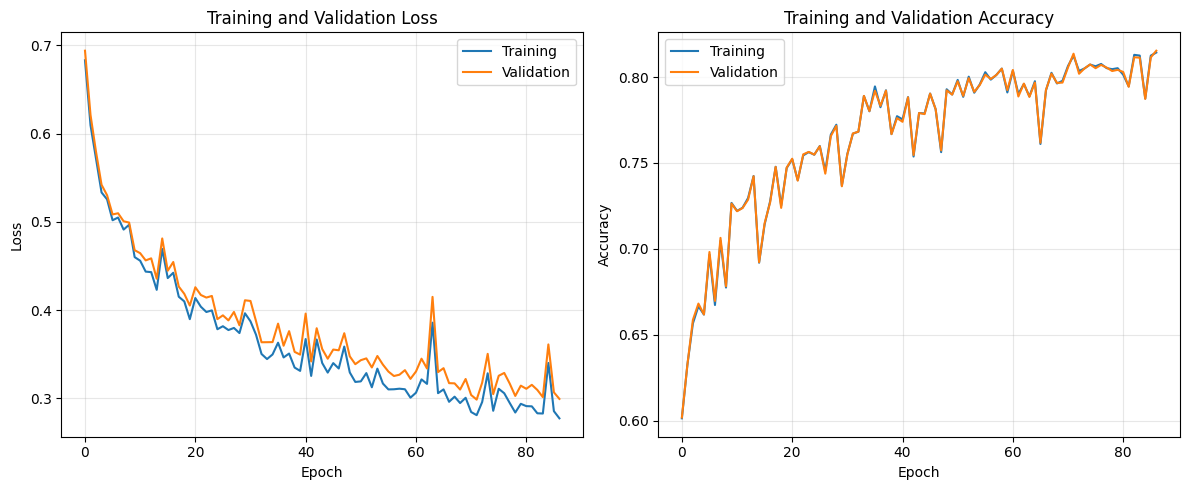

In [27]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Training")
plt.plot(history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history["train_accuracy"], label="Training")
plt.plot(history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


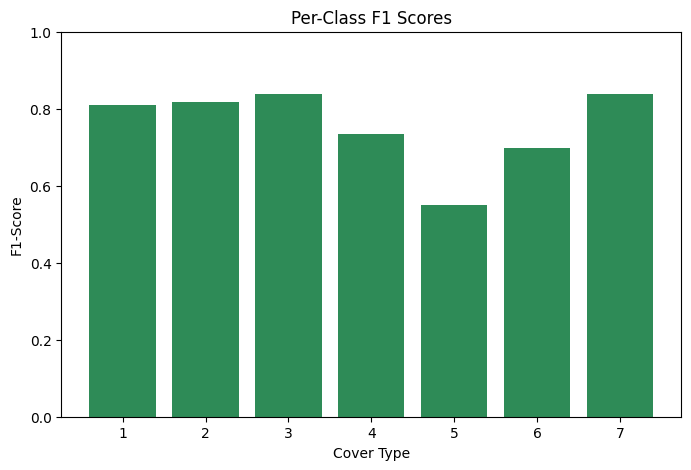

In [28]:
plt.figure(figsize=(8, 5))

plt.bar(
    range(1, 8),
    f1,
    color="seagreen"
)

plt.xlabel("Cover Type")
plt.ylabel("F1-Score")
plt.title("Per-Class F1 Scores")
plt.xticks(range(1, 8))
plt.ylim(0, 1)
plt.show()

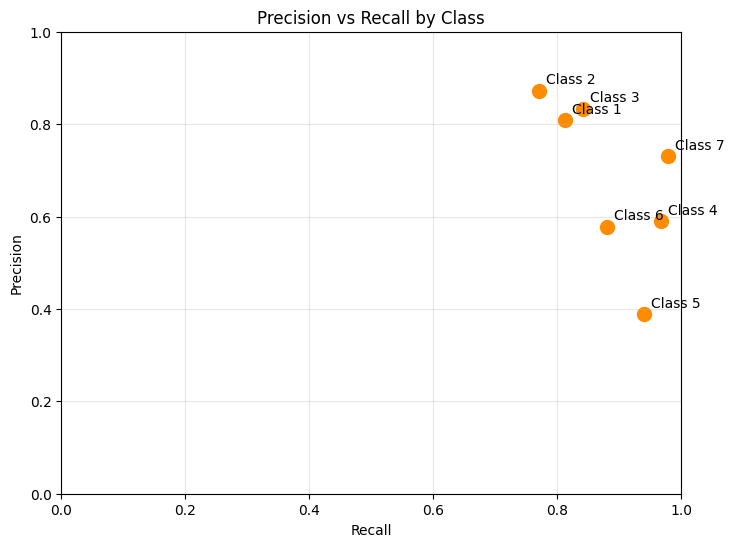

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(
    recall,
    precision,
    s=100,
    color="darkorange"
)

for i in range(7):
    plt.annotate(
        f"Class {i + 1}",
        (recall[i], precision[i]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall by Class")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.show()

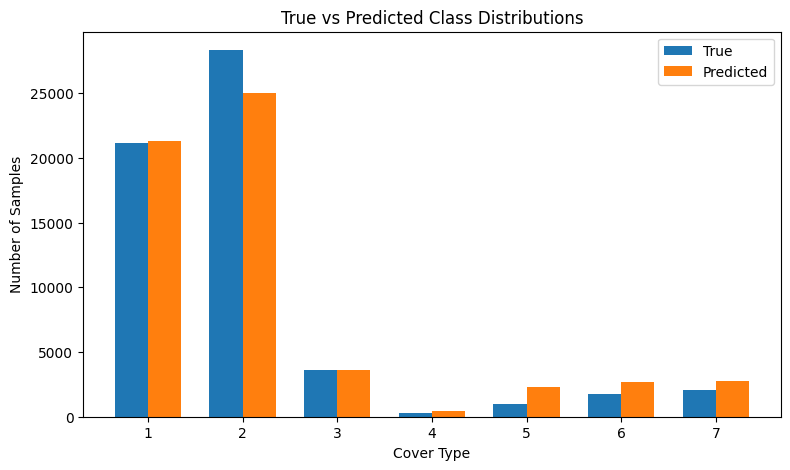

In [30]:
true_counts = np.bincount(
    y_test,
    minlength=7
)

pred_counts = np.bincount(
    y_pred,
    minlength=7
)

x = np.arange(1, 8)
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    true_counts,
    width,
    label="True"
)

plt.bar(
    x + width / 2,
    pred_counts,
    width,
    label="Predicted"
)

plt.xlabel("Cover Type")
plt.ylabel("Number of Samples")
plt.title("True vs Predicted Class Distributions")
plt.xticks(x)
plt.legend()
plt.show()